In [2]:
import xraylib as xrl 
import numpy as np
import math
import scipy.constants as constants
import matplotlib.pyplot as plt

In [ ]:
## Constants and Conversions
joule_to_ev = constants.physical_constants['joule-electron volt relationship'][0]

Text(0.5, 1.0, 'Material Properties vs. X-ray Energy')

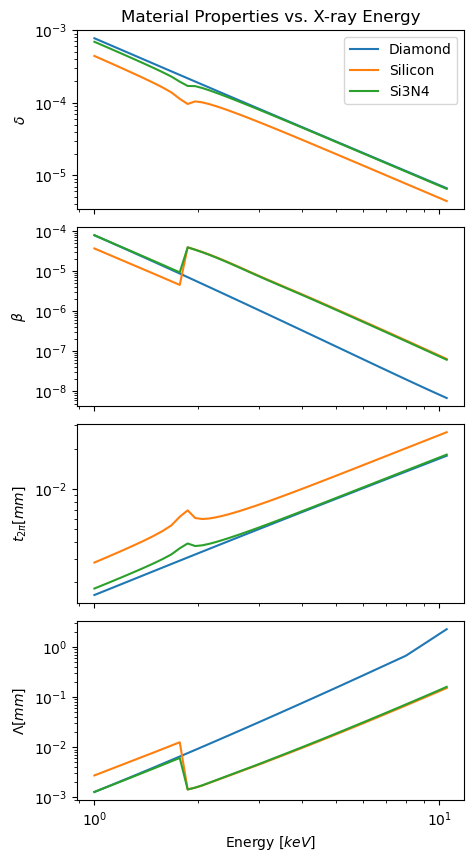

In [102]:
E_min, E_max = 1, 10.5 ## keV
E_range = np.linspace(E_min, E_max, 100)

### (Symbol, Mass Density (g/cm^3))
materials = {"Diamond": ("C", 3.53), 
             "Silicon": ("Si", 2.329), 
             "Si3N4": ("Si3N4", 3.44)}

fig, ax = plt.subplots(figsize=(5, 10), nrows=4, sharex=True, squeeze=False)
plt.subplots_adjust(hspace=0.1)

for material in materials:
    sym, rho_m = materials[material]
    deltas = np.array([1-xrl.Refractive_Index_Re(sym,E,rho_m) for E in E_range])
    betas = np.array([xrl.Refractive_Index_Im(sym,E,rho_m) for E in E_range])
    lambdas = (constants.h*constants.c)*joule_to_ev/(E_range*1e3) ## units m
    t = lambdas/deltas*1000 ## units mm

    sigma_a = np.array([xrl.CS_Energy_CP(sym, E) for E in E_range]) ## units cm^2/g
    Lambdas = 1/(rho_m*sigma_a)*10 ## units mm
    
    ax[0, 0].plot(E_range, deltas, label=material)
    ax[0, 0].set(ylabel=r"$\delta$", yscale="log")
    ax[1, 0].plot(E_range, betas)
    ax[1, 0].set(ylabel=r"$\beta$", yscale="log")
    ax[2, 0].plot(E_range, t)
    ax[2, 0].set(ylabel=r"$t_{2\pi} [mm]$", yscale="log")
    ax[3, 0].plot(E_range, Lambdas)
    ax[3, 0].set(ylabel=r"$\Lambda [mm]$", yscale="log")
    
ax[-1, 0].set(xlabel="Energy $[keV]$", xscale="log")
ax[0, 0].legend()
ax[0, 0].set_title("Material Properties vs. X-ray Energy")
    
    